# 01. Gold Candidate Pool 구성

기존 `goldset_final.json`을 기반으로 reranking 실험용 후보군을 구성한다.

- **입력**: `evaluation/dataset/goldset_final.json`, `evaluation/dataset/scenario_data_after_retrieval.json`
- **출력**: `experiments/rerank/data/gold_candidate_pool.json`

`goldset_final.json`은 BM25 + Dense + Hybrid 세 retrieval 결과의 합집합(중복 제거)이며,
각 도서의 relevance grade는 LLM judge 3회 다수결로 선정된 값이다.
모든 후보를 그대로 사용하고, Variant D용 `retrieval_rank`/`retrieval_score`는 hybrid → dense → bm25 우선순위로 첨부한다.

In [2]:
import json
import sys
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'

ROOT = Path('../../..')
EVAL_DIR = ROOT / 'evaluation' / 'dataset'
OUT_DIR = Path('../data')
OUT_DIR.mkdir(exist_ok=True)

## 1. 데이터 로드

In [3]:
with open(EVAL_DIR / 'goldset_final_corrected.json') as f:
    goldset = json.load(f)

with open(EVAL_DIR / 'scenario_data_after_retrieval.json') as f:
    scenario_data = json.load(f)

print(f'goldset 총 도서 수: {len(goldset)}')
print(f'시나리오 수: {len(scenario_data)}')

goldset 총 도서 수: 2519
시나리오 수: 21


In [4]:
# 시나리오별 semantic_query 추출 (마지막 turn의 rag_query)
scenario_query_map = {}
for s in scenario_data:
    sid = s['scenario_id']
    for turn in s.get('turns', []):
        if 'rag_query' in turn:
            scenario_query_map[sid] = turn['rag_query'].get('semantic_query', '')

print(f'semantic_query 추출된 시나리오: {len(scenario_query_map)}개')
for sid, q in list(scenario_query_map.items())[:3]:
    print(f'  {sid}: {q[:60]}...')

semantic_query 추출된 시나리오: 21개
  S01: 실존주의적 주제를 중심으로 듦에 대한 철학적 사유를 유도하며 삶의 지혜를 탐구하는 에세이...
  S02: 경영 리더십 원칙을 실무에 바로 적용할 수 있는 경제 이론 비판 및 현실적 대안을 제시하는 책...
  S03: 우주와 물리학 개념을 이야기 형식으로 풀어낸 교양과학 책 추천...


## 2. 시나리오별 후보군 구성

goldset의 모든 도서를 사용한다 (BM25 + Dense + Hybrid 합집합, 중복 제거).
Variant D용 retrieval_rank/score는 hybrid → dense → bm25 우선순위로 선택한다.

In [5]:
RELEVANT_THRESHOLD = 2  # final_grade >= 2 → relevant
SOURCE_PRIORITY = ['hybrid', 'dense', 'bm25']  # Variant D용 rank/score 우선순위

def pick_retrieval_info(retrieval_info: list) -> dict | None:
    """hybrid → dense → bm25 순으로 첫 번째로 찾은 retrieval 정보 반환"""
    info_by_source = {r['source']: r for r in retrieval_info}
    for src in SOURCE_PRIORITY:
        if src in info_by_source:
            return info_by_source[src]
    return None

# 시나리오별 후보 그룹화 (소스 필터 없이 전체 사용)
scenario_books = defaultdict(list)
for book in goldset:
    sid = book['query_id']
    retrieval_info = book.get('retrieval_info', [])
    ref = pick_retrieval_info(retrieval_info)  # Variant D용 대표 rank/score

    candidate = {
        # 메타데이터
        'isbn': book['isbn'],
        'title': book.get('title', ''),
        'author': book.get('author', ''),
        'publisher': book.get('publisher', ''),
        'large_cate': book.get('large_cate', []),
        'mid_cate': book.get('mid_cate', []),
        'small_cate': book.get('small_cate', []),
        'book_intro': book.get('book_intro', ''),
        'book_index': book.get('book_index', ''),
        'review_text': book.get('review_text', ''),
        # relevance (final_grade 하나로 통일 — binary는 평가 코드에서 threshold 적용)
        'final_grade': book.get('final_grade', 0),
        # retrieval 신호 (Variant D, E용) — 대표 소스 기준
        'retrieval_source': ref['source'] if ref else None,
        'retrieval_rank':   ref.get('rank')  if ref else None,
        'retrieval_score':  ref.get('score') if ref else None,
        # 소스별 원본 정보 (참고용)
        'retrieval_info': retrieval_info,
    }
    scenario_books[sid].append(candidate)

# 정렬: 소스 전체에서 가장 낮은 rank 기준 (cross-encoder는 순서 무관하지만 열람 편의용)
for sid in scenario_books:
    scenario_books[sid].sort(key=lambda c: min(
        (r.get('rank') or 999 for r in c['retrieval_info']), default=999
    ))

print('시나리오별 후보 수:')
for sid in sorted(scenario_books):
    cands = scenario_books[sid]
    n_rel = sum(1 for c in cands if c['final_grade'] >= RELEVANT_THRESHOLD)
    sources = set(r['source'] for c in cands for r in c['retrieval_info'])
    print(f'  {sid}: {len(cands)}개 (relevant {n_rel}개) | sources: {sources}')

시나리오별 후보 수:
  S01: 113개 (relevant 17개) | sources: {'hybrid_strategy1', 'bm25_full', 'dense_strategy0', 'hybrid_strategy0', 'dense_strategy2', 'hybrid_strategy2', 'dense_strategy1'}
  S02: 115개 (relevant 9개) | sources: {'hybrid_strategy1', 'bm25_full', 'dense_strategy0', 'hybrid_strategy0', 'dense_strategy2', 'hybrid_strategy2', 'dense_strategy1'}
  S03: 85개 (relevant 5개) | sources: {'hybrid_strategy1', 'dense_strategy2', 'dense_strategy0', 'bm25_full', 'hybrid_strategy0', 'hybrid_strategy2', 'dense_strategy1'}
  S04: 102개 (relevant 18개) | sources: {'hybrid_strategy1', 'bm25_full', 'dense_strategy0', 'hybrid_strategy0', 'dense_strategy2', 'hybrid_strategy2', 'dense_strategy1'}
  S05: 130개 (relevant 11개) | sources: {'hybrid_strategy1', 'bm25_full', 'dense_strategy0', 'hybrid_strategy0', 'dense_strategy2', 'hybrid_strategy2', 'dense_strategy1'}
  S06: 119개 (relevant 48개) | sources: {'hybrid_strategy1', 'dense_strategy2', 'bm25_full', 'dense_strategy0', 'hybrid_strategy0', 'hybrid_strategy

## 3. 기초 통계 시각화

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

/tmp/ipykernel_39584/3827994937.py:26: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.savefig('../data/gold_pool_stats.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_39584/3827994937.py:26: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.savefig('../data/gold_pool_stats.png', dpi=150, bbox_inches='tight')
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not

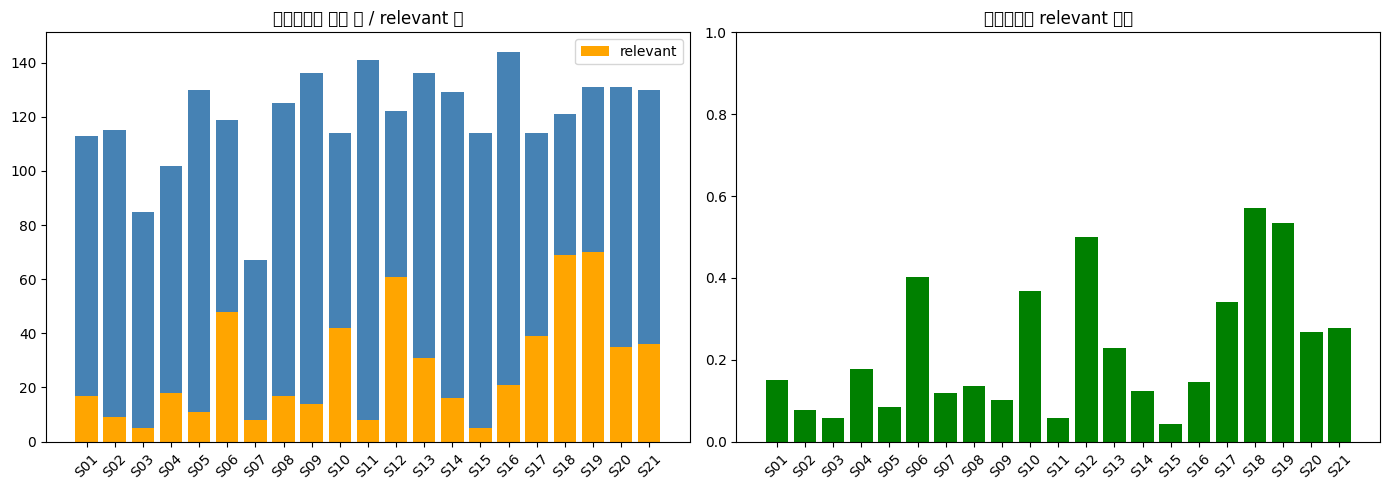

scenario_id  n_candidates  n_relevant  relevant_ratio
        S01           113          17        0.150442
        S02           115           9        0.078261
        S03            85           5        0.058824
        S04           102          18        0.176471
        S05           130          11        0.084615
        S06           119          48        0.403361
        S07            67           8        0.119403
        S08           125          17        0.136000
        S09           136          14        0.102941
        S10           114          42        0.368421
        S11           141           8        0.056738
        S12           122          61        0.500000
        S13           136          31        0.227941
        S14           129          16        0.124031
        S15           114           5        0.043860
        S16           144          21        0.145833
        S17           114          39        0.342105
        S18           121   

In [6]:
stats = [
    {
        'scenario_id': sid,
        'n_candidates': len(cands),
        'n_relevant': sum(1 for c in cands if c['final_grade'] >= RELEVANT_THRESHOLD),
        'relevant_ratio': sum(1 for c in cands if c['final_grade'] >= RELEVANT_THRESHOLD) / len(cands) if cands else 0,
    }
    for sid, cands in sorted(scenario_books.items())
]
df = pd.DataFrame(stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df['scenario_id'], df['n_candidates'], color='steelblue')
axes[0].bar(df['scenario_id'], df['n_relevant'], color='orange', label='relevant')
axes[0].set_title('시나리오별 후보 수 / relevant 수')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

axes[1].bar(df['scenario_id'], df['relevant_ratio'], color='green')
axes[1].set_title('시나리오별 relevant 비율')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/gold_pool_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print(df.to_string(index=False))

In [14]:
def is_hard_negative(book, rank_threshold=10, min_sources=2):
    """
    여러 retrieval에서 상위권에 올라온 grade 1 책
    → retrieval이 여러 번 속은 것 = 진짜 헷갈리는 케이스
    """
    retrieval_info = book.get("retrieval_info", [])
    high_rank_sources = [
        r for r in retrieval_info
        if r.get("rank") is not None and r["rank"] <= rank_threshold
    ]
    return (
        book["final_grade"] == 1
        and len(high_rank_sources) >= min_sources
    )

# Hard Negative 파라미터
HARD_NEG_TOP_K       = 10
HARD_NEG_MIN_SOURCES = 2   # 2개 이상 retrieval 소스에서 top-K 내 랭킹

# 시나리오별 hard negative 집계
hn_rows = []
for sid, cands in sorted(scenario_books.items()):
    hard_negs = [c for c in cands if is_hard_negative(c, HARD_NEG_TOP_K, HARD_NEG_MIN_SOURCES)]
    hn_rows.append({
        'scenario_id'    : sid,
        'n_candidates'   : len(cands),
        'n_grade1'       : sum(1 for c in cands if c['final_grade'] == 1),
        'n_hard_neg'     : len(hard_negs),
        'hard_neg_titles': [c['title'][:20] for c in hard_negs],
    })

hn_df = pd.DataFrame(hn_rows)

# ── 전체 요약 ──────────────────────────────────────────────────────────
total_grade1   = hn_df['n_grade1'].sum()
total_hard_neg = hn_df['n_hard_neg'].sum()
print(f'[Hard Negative 요약]  (grade=1, top-{HARD_NEG_TOP_K}, min_sources={HARD_NEG_MIN_SOURCES})')
print(f'  전체 grade-1 도서          : {total_grade1:,}개')
print(f'  그 중 {HARD_NEG_MIN_SOURCES}개+ 소스 top-{HARD_NEG_TOP_K} 내  : {total_hard_neg:,}개  ({total_hard_neg/total_grade1*100:.1f}%)')

# ── 시나리오별 상세 ────────────────────────────────────────────────────
print(f"\n{'scenario_id':>12}  {'grade-1':>8}  {'hard_neg':>9}  {'비율':>7}  titles")
print('-' * 80)
for _, row in hn_df.iterrows():
    ratio = row['n_hard_neg'] / row['n_grade1'] * 100 if row['n_grade1'] > 0 else 0
    titles = ', '.join(row['hard_neg_titles'][:3]) + ('…' if len(row['hard_neg_titles']) > 3 else '')
    print(f"{row['scenario_id']:>12}  {row['n_grade1']:>8}  {row['n_hard_neg']:>9}  {ratio:>6.1f}%  {titles}")


[Hard Negative 요약]  (grade=1, top-10, min_sources=2)
  전체 grade-1 도서          : 1,679개
  그 중 2개+ 소스 top-10 내  : 179개  (10.7%)

 scenario_id   grade-1   hard_neg       비율  titles
--------------------------------------------------------------------------------
         S01        87         10    11.5%  그렇게 나를 만들어간다, 이수의 일기, 인생독서 -  100그램 1…
         S02        96         14    14.6%  발칙한 경제학 - 세상을 움직이는 힘, 시장경제의 약속 - 그래도 성장이 희, 전자상거래와 디지털 경제…
         S03        47          6    12.8%  과학책 읽어주는 공대생 - 요즘 공대, 원소의 구조 - 개념이 술술! 이해가, 재밌어서 밤새 읽는 수학 이야기 : …
         S04        79          9    11.4%  카네기 인간경영 리더십, 조직과 리더십, 리더십의 이론과 진단…
         S05       108         11    10.2%  노년에 관한 인문학적 성찰, 노인은 아름다운 이름이다, 이탈리아 한 접시 - 접시 시리즈 …
         S06        69          4     5.8%  성공하는 사람들의 인간관계, 데일 카네기와의 티타임, 나와 같은 너에게 - 우울증 치료일기…
         S07        29          4    13.8%  재테크는 지테크다, 존리와 함께 떠나는 부자 여행 1 :, 답답한 주식투자 현명한 채권투자…
         S08        90         15    16.7%  소설 청향비3 - P, 자칼의 날 1 = The Day of

In [15]:
gold_pool = [
    {
        'scenario_id': sid,
        'semantic_query': scenario_query_map.get(sid, ''),
        'n_candidates': len(cands),
        'n_relevant': sum(1 for c in cands if c['final_grade'] >= RELEVANT_THRESHOLD),
        'candidates': cands,
    }
    for sid, cands in sorted(scenario_books.items())
]

out_path = OUT_DIR / 'gold_candidate_pool.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(gold_pool, f, ensure_ascii=False, indent=2)

print(f'저장 완료: {out_path}')
print(f'총 {len(gold_pool)}개 시나리오, {sum(s["n_candidates"] for s in gold_pool)}개 후보')
print(f'총 relevant: {sum(s["n_relevant"] for s in gold_pool)}개')

저장 완료: ../data/gold_candidate_pool.json
총 21개 시나리오, 2519개 후보
총 relevant: 580개
